# Predict Students' Dropout and Academic Success

### Part 1: Data Exploration

In [36]:
# load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from pycaret.classification import *

In [5]:
# load dataset

df = pd.read_csv("data/raw/data.csv",
    sep=";")

# Clean column names
df.columns = df.columns.str.strip()
# show first rows
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### exploratory analysis on dataset

In [6]:
df.shape

(4424, 37)

In [7]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [9]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

##### Bar Chart showing the target class and how it is distributed 

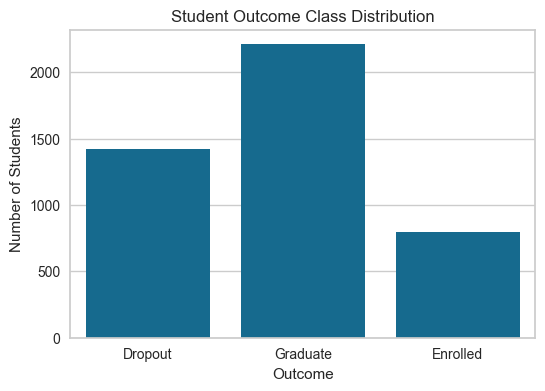

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Target"
)

plt.title("Student Outcome Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")

plt.show()

In [11]:
# count of null values in dataset
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

##### Feature Distributions 

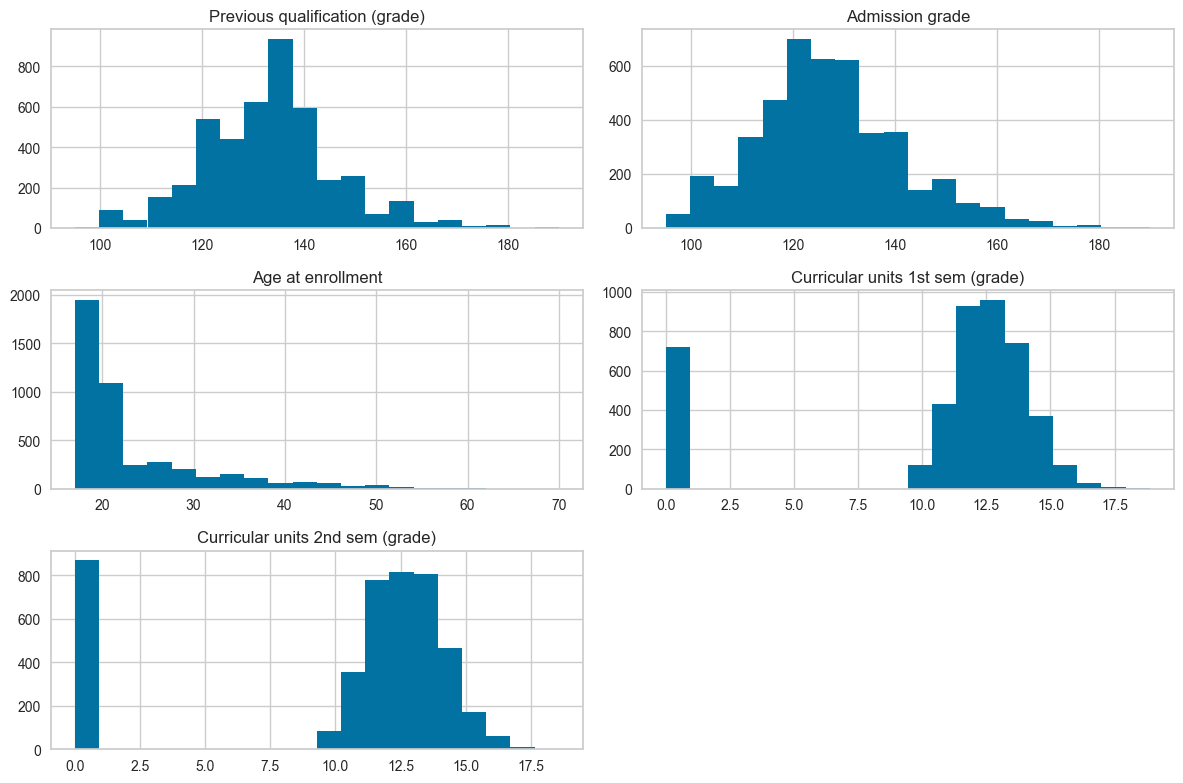

In [12]:
continuous_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
]

df[continuous_features].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

#### Tuition Fees Payed and Scholarship Based on Target

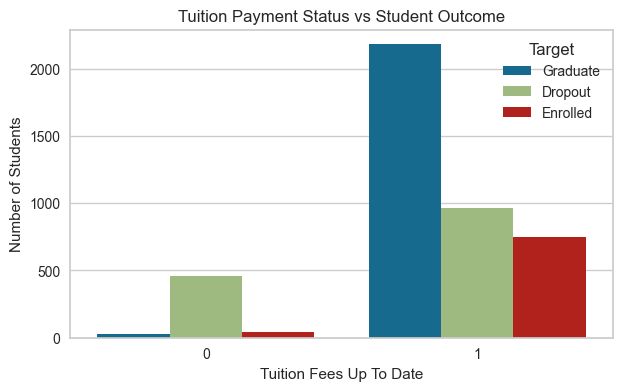

In [13]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Tuition fees up to date",
    hue="Target"
)

plt.title("Tuition Payment Status vs Student Outcome")
plt.xlabel("Tuition Fees Up To Date")
plt.ylabel("Number of Students")

plt.show()

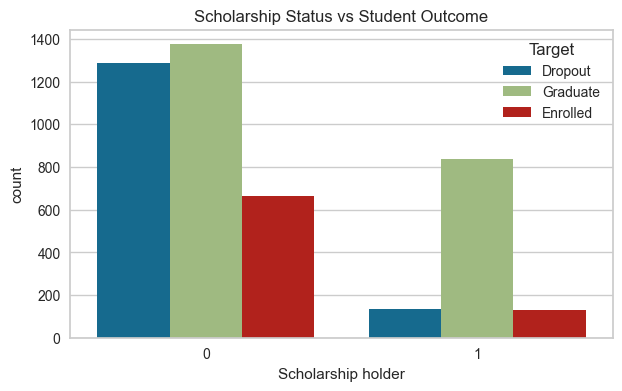

In [14]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Scholarship holder",
    hue="Target"
)

plt.title("Scholarship Status vs Student Outcome")

plt.show()

##### Correlation Map

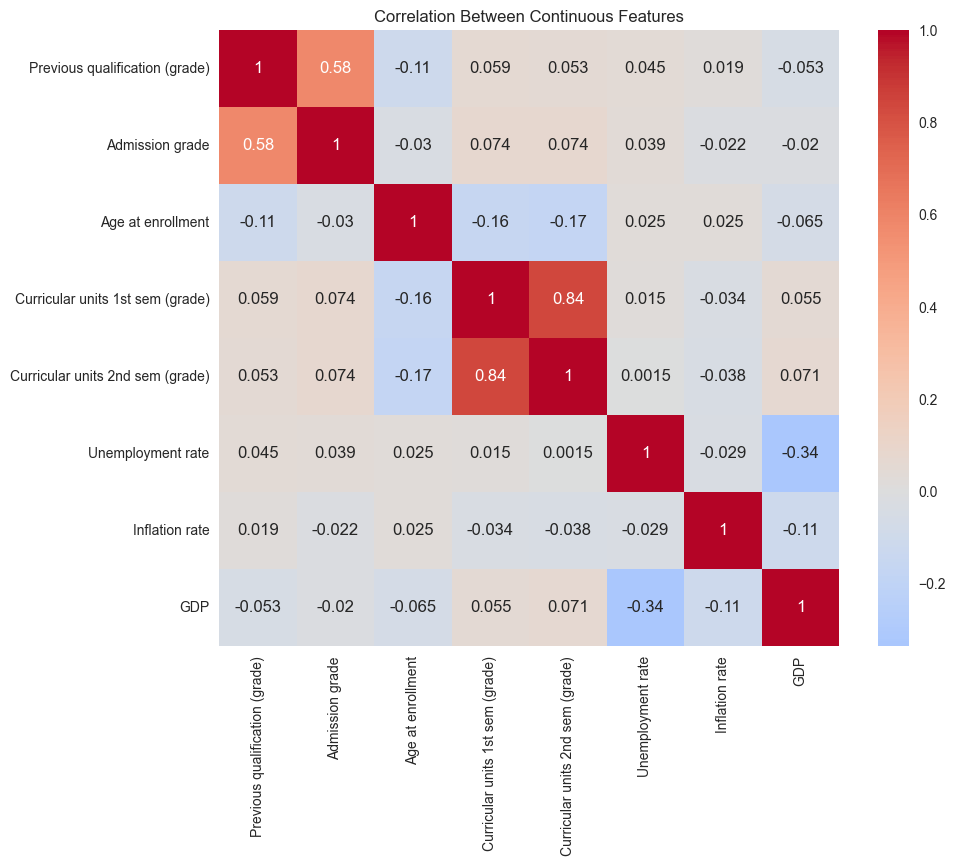

In [15]:
# Select continuous numerical features only
continuous_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

plt.figure(figsize=(10,8))

corr = df[continuous_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Continuous Features")
plt.show()

### Prep Data for Modeling

In [16]:
# Separate features and target
X = df.drop("Target", axis=1)
y = df["Target"]

# Encode target classes
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


In [17]:
# Define categorical features
categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

# Define numerical features
numerical_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [18]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (3539, 256)
Testing shape: (885, 256)


### Part 2: Machine Learning

##### Model 1: Logistic Regression

In [19]:

# Create Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# measure training time
start_train = time.perf_counter()

log_reg_model.fit(X_train, y_train)

end_train = time.perf_counter()
training_time = end_train - start_train

# measure prediction time
start_query = time.perf_counter()
predictions = log_reg_model.predict(X_test)

end_query = time.perf_counter()

query_time = end_query - start_query

# calculate accuracy
train_predictions = log_reg_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, predictions)

# print results
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Training Time     : {training_time:.6f} seconds")
print(f"Query Time        : {query_time:.6f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, predictions)

print(pd.DataFrame(
    cm,
    index=[f"Actual {class_name}" for class_name in label_encoder.classes_],
    columns=[f"Predicted {class_name}" for class_name in label_encoder.classes_]
))



Training Accuracy : 0.6861
Testing Accuracy  : 0.6588
Training Time     : 0.973833 seconds
Query Time        : 0.002121 seconds

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.75      0.59      0.66       316
    Enrolled       0.29      0.03      0.06       151
    Graduate       0.63      0.94      0.75       418

    accuracy                           0.66       885
   macro avg       0.56      0.52      0.49       885
weighted avg       0.62      0.66      0.60       885


Confusion Matrix:
                 Predicted Dropout  Predicted Enrolled  Predicted Graduate
Actual Dropout                 187                   9                 120
Actual Enrolled                 37                   5                 109
Actual Graduate                 24                   3                 391


#### Model 2: Decision Tree

In [20]:
# Create default Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
train_predictions = dt_model.predict(X_train)
test_predictions = dt_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy : 0.6768


#####  experiment with different values for max_depth

In [21]:
depth_values = range(1, 21)

train_scores = []
test_scores = []

for depth in depth_values:
    
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    train_scores.append(
        accuracy_score(y_train, train_predictions)
    )
    
    test_scores.append(
        accuracy_score(y_test, test_predictions)
    )


##### model complexity curve that graphs the training and testing accuracy against the value of max_depth

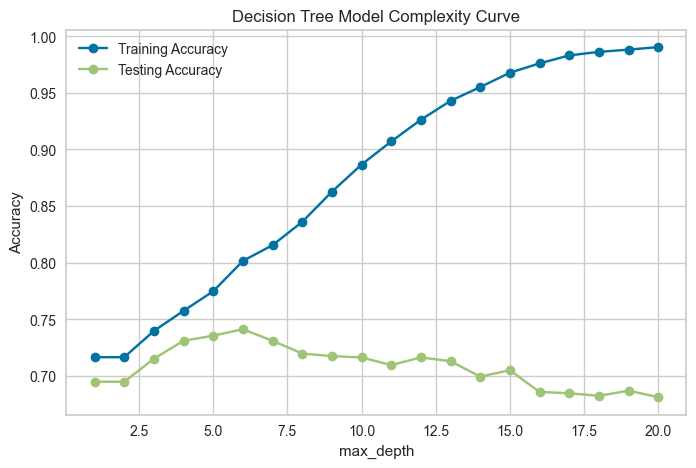

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    depth_values,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_values,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Model Complexity Curve")

plt.legend()
plt.grid(True)

plt.show()

##### find best max_depth

In [23]:
best_depth = depth_values[test_scores.index(max(test_scores))]

print("Best max_depth:", best_depth)
print("Best Testing Accuracy:", max(test_scores))

Best max_depth: 6
Best Testing Accuracy: 0.7412429378531074


In [24]:
# train best max_deptj

best_dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

# Measure training time
start_train = time.perf_counter()

best_dt_model.fit(X_train, y_train)

end_train = time.perf_counter()

training_time = end_train - start_train


# Measure query time
start_query = time.perf_counter()

predictions = best_dt_model.predict(X_test)

end_query = time.perf_counter()

query_time = end_query - start_query

#  calculate final scores
train_predictions = best_dt_model.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    predictions
)
print(f"max_depth: {best_depth}")
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Training Time     : {training_time:.6f} seconds")
print(f"Query Time        : {query_time:.6f} seconds")

max_depth: 6
Training Accuracy : 0.8016
Testing Accuracy  : 0.7412
Training Time     : 0.026799 seconds
Query Time        : 0.002408 seconds


##### Model 3: AutoML & Hyperparameter Tuning

In [26]:
# Start timer
start_time = time.time()

# Initialize PyCaret
setup(data=df,
      target='Target',
      session_id=42)

# Compare multiple models

best_model = compare_models(    
    sort='Accuracy',
    budget_time=120
)

# End timer
training_time = time.time() - start_time

print("Training/Search Time:", training_time)
print("Best Model:", best_model)

,Description,Value
0,Session id,42
1,Target,Target
2,Target type,Multiclass
3,Target mapping,"Dropout: 0, Enrolled: 1, Graduate: 2"
4,Original data shape,"(4424, 37)"
5,Transformed data shape,"(4424, 37)"
6,Transformed train set shape,"(3096, 37)"
7,Transformed test set shape,"(1328, 37)"
8,Numeric features,36
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7755,0.9008,0.7755,0.7634,0.7584,0.6171,0.6281,0.1240
rf,Random Forest Classifier,0.7707,0.9012,0.7707,0.7534,0.7535,0.6108,0.6194,0.1290
gbc,Gradient Boosting Classifier,0.7707,0.0000,0.7707,0.7572,0.7574,0.6130,0.6199,0.6260
lda,Linear Discriminant Analysis,0.7561,0.0000,0.7561,0.7557,0.7458,0.5868,0.5980,0.0230
ridge,Ridge Classifier,0.7506,0.0000,0.7506,0.7279,0.7114,0.5617,0.5886,0.0150
ada,Ada Boost Classifier,0.7464,0.0000,0.7464,0.7313,0.7350,0.5759,0.5796,0.0840
lr,Logistic Regression,0.7216,0.0000,0.7216,0.6996,0.7009,0.5257,0.5351,0.9180
qda,Quadratic Discriminant Analysis,0.7154,0.0000,0.7154,0.7001,0.7040,0.5235,0.5275,0.0160
dt,Decision Tree Classifier,0.6948,0.7619,0.6948,0.6959,0.6946,0.5043,0.5050,0.0200
nb,Naive Bayes,0.6835,0.8123,0.6835,0.6634,0.6678,0.4657,0.4712,0.0160


Training/Search Time: 24.69023871421814
Best Model: ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=42, verbose=0,
                     warm_start=False)


In [27]:
# Record top 5 models
results = pull()
results.head(5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7755,0.9008,0.7755,0.7634,0.7584,0.6171,0.6281,0.124
rf,Random Forest Classifier,0.7707,0.9012,0.7707,0.7534,0.7535,0.6108,0.6194,0.129
gbc,Gradient Boosting Classifier,0.7707,0.0000,0.7707,0.7572,0.7574,0.6130,0.6199,0.626
lda,Linear Discriminant Analysis,0.7561,0.0000,0.7561,0.7557,0.7458,0.5868,0.5980,0.023
ridge,Ridge Classifier,0.7506,0.0000,0.7506,0.7279,0.7114,0.5617,0.5886,0.015


In [33]:
# training accuracy
train_results = predict_model(best_model)

train_accuracy = (train_results['prediction_label'] 
                  == train_results['Target']).mean()

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.7710843373493976


In [34]:
# testing accuracy
start_query = time.time()

test_results = predict_model(
    best_model,
    data=get_config('test')
)

query_time = time.time() - start_query

test_accuracy = (test_results['prediction_label'] 
                 == test_results['Target']).mean()

print("Testing Accuracy:", test_accuracy)
print("Query Time:", query_time)

Testing Accuracy: 0.7710843373493976
Query Time: 0.3516683578491211


##### Model 4: Random Forest

##### check for max_depth

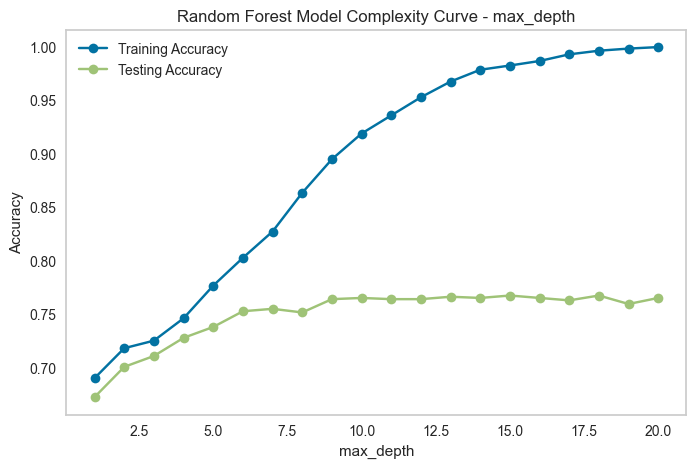

In [39]:
# Test different max_depth values
depth_values = range(1, 21)

train_accuracy_depth = []
test_accuracy_depth = []

for depth in depth_values:
    
    rf = RandomForestClassifier(
        max_depth=depth,
        n_estimators=100,
        random_state=42
    )
    
    start_time = time.time()
    
    rf.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    train_accuracy_depth.append(
        accuracy_score(y_train, rf.predict(X_train))
    )
    
    test_accuracy_depth.append(
        accuracy_score(y_test, rf.predict(X_test))
    )


# Plot model complexity curve
plt.figure(figsize=(8,5))

plt.plot(depth_values, train_accuracy_depth, marker='o', label="Training Accuracy")
plt.plot(depth_values, test_accuracy_depth, marker='o', label="Testing Accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Random Forest Model Complexity Curve - max_depth")
plt.legend()
plt.grid()

plt.show()


##### check for n_estimators

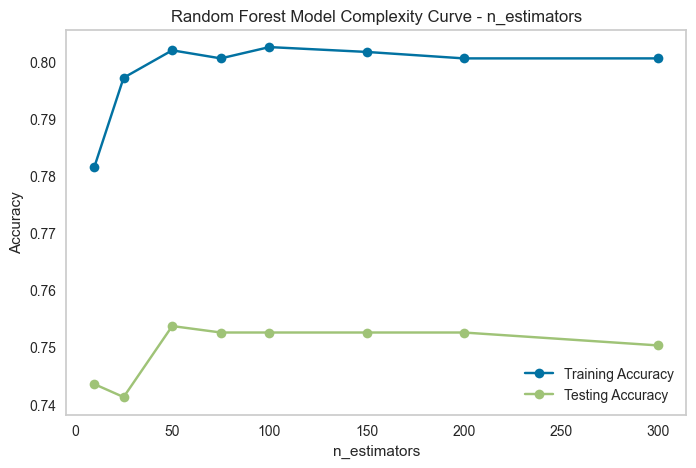

In [40]:
# Test different n_estimators values using chosen max_depth
n_estimators_values = [10, 25, 50, 75, 100, 150, 200, 300]

train_accuracy_estimators = []
test_accuracy_estimators = []

for n in n_estimators_values:
    
    rf = RandomForestClassifier(
        max_depth=6,
        n_estimators=n,
        random_state=42
    )
    start_time = time.time()
    
    rf.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    train_accuracy_estimators.append(
        accuracy_score(y_train, rf.predict(X_train))
    )
    
    
    test_accuracy_estimators.append(
        accuracy_score(y_test, rf.predict(X_test))
    )
# Plot n_estimators complexity curve
plt.figure(figsize=(8,5))

plt.plot(
    n_estimators_values, 
    train_accuracy_estimators, 
    marker='o',
    label="Training Accuracy"
)

plt.plot(
    n_estimators_values, 
    test_accuracy_estimators, 
    marker='o',
    label="Testing Accuracy"
)

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest Model Complexity Curve - n_estimators")
plt.legend()
plt.grid()

plt.show()

##### random forest model with best max_depth and n_estimators

In [42]:
max_depth = 6
n_estimators = 50

# Final Random Forest model
final_rf = RandomForestClassifier(
    max_depth=6,
    n_estimators=50,
    random_state=42
)

# Training time
start_train = time.time()

final_rf.fit(X_train, y_train)

training_time = time.time() - start_train


# Training accuracy
train_predictions = final_rf.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)


# Query (prediction) time and testing accuracy
start_query = time.time()

test_predictions = final_rf.predict(X_test)

query_time = time.time() - start_query

test_accuracy = accuracy_score(y_test, test_predictions)


# Results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Query Time: {query_time:.4f} seconds")

Training Accuracy: 0.8019
Testing Accuracy: 0.7537
Training Time: 0.4860 seconds
Query Time: 0.0177 seconds


Predict Students' Dropout and Academic Success Dataset:
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
